In [1]:
# import libraries

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np 
import missingno as msno

In [2]:
# Data Loading

data = pd.read_csv("../data/booking.csv")

In [3]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [4]:
data.shape

(36285, 17)

In [5]:
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  str    
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  str    
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  str    
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  str    
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  special requests 

In [7]:
# Data Cleaning

In [8]:
data.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['date of reservation'] = pd.to_datetime(
    data['date of reservation'],
    errors='coerce'
)

In [11]:
data['date of reservation'].isnull().sum()

np.int64(37)

In [12]:
data[data['date of reservation'].isnull()]

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
2626,INN02627,2,0,1,5,Meal Plan 1,0,Room_Type 1,104,Online,1,1,0,61.43,0,NaT,Canceled
3677,INN03678,1,0,1,3,Meal Plan 1,0,Room_Type 1,21,Online,0,0,0,102.05,0,NaT,Canceled
5600,INN05601,2,0,1,3,Meal Plan 1,0,Room_Type 1,24,Offline,0,0,0,45.50,0,NaT,Not_Canceled
6343,INN06344,1,0,1,1,Meal Plan 1,0,Room_Type 1,117,Offline,0,0,0,76.00,0,NaT,Not_Canceled
7648,INN07649,2,1,1,5,Meal Plan 1,0,Room_Type 1,35,Online,0,0,0,98.10,1,NaT,Canceled
8000,INN08001,2,2,1,3,Meal Plan 1,0,Room_Type 6,3,Online,0,0,0,183.00,1,NaT,Not_Canceled
8989,INN08990,1,0,1,2,Meal Plan 1,0,Room_Type 1,117,Offline,0,0,0,76.00,0,NaT,Not_Canceled
9153,INN09154,2,2,1,3,Meal Plan 1,0,Room_Type 6,3,Online,0,0,0,189.75,0,NaT,Not_Canceled
9245,INN09246,2,0,1,3,Meal Plan 1,0,Room_Type 4,15,Online,0,0,0,85.55,1,NaT,Not_Canceled
9664,INN09665,1,0,1,0,Meal Plan 1,0,Room_Type 4,21,Online,0,0,0,117.00,0,NaT,Not_Canceled


In [13]:
data['date of reservation'].unique()

<DatetimeArray>
['2015-10-02 00:00:00', '2018-11-06 00:00:00', '2018-02-28 00:00:00',
 '2017-05-20 00:00:00', '2018-04-11 00:00:00', '2016-09-13 00:00:00',
 '2017-10-15 00:00:00', '2018-12-26 00:00:00', '2018-07-06 00:00:00',
 '2018-10-18 00:00:00',
 ...
 '2017-07-20 00:00:00', '2017-07-22 00:00:00', '2017-07-28 00:00:00',
 '2017-07-24 00:00:00', '2017-07-12 00:00:00', '2017-07-03 00:00:00',
 '2017-07-19 00:00:00', '2017-07-14 00:00:00', '2017-08-02 00:00:00',
 '2017-07-21 00:00:00']
Length: 553, dtype: datetime64[us]

In [14]:
data.isnull().sum()

Booking_ID                   0
number of adults             0
number of children           0
number of weekend nights     0
number of week nights        0
type of meal                 0
car parking space            0
room type                    0
lead time                    0
market segment type          0
repeated                     0
P-C                          0
P-not-C                      0
average price                0
special requests             0
date of reservation         37
booking status               0
dtype: int64

In [15]:
data.dropna(inplace= True)

#### The data was checked for missing values, duplicate records, and incorrect data types. The reservation date column was converted to datetime format, and invalid date records were removed to improve data quality.

In [16]:
# Extract the year,month, and quater

data['Year']=data['date of reservation'].dt.year
data['Month']=data['date of reservation'].dt.month
data['Month_name']=data['date of reservation'].dt.month_name()
data['Quarter']=data['date of reservation'].dt.quarter
data['Day_of_week']=data['date of reservation'].dt.day_name()

data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,...,P-not-C,average price,special requests,date of reservation,booking status,Year,Month,Month_name,Quarter,Day_of_week
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,...,0,88.00,0,2015-10-02,Not_Canceled,2015,10,October,4,Friday
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,...,0,106.68,1,2018-11-06,Not_Canceled,2018,11,November,4,Tuesday
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,...,0,50.00,0,2018-02-28,Canceled,2018,2,February,1,Wednesday
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,...,0,100.00,1,2017-05-20,Canceled,2017,5,May,2,Saturday
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,...,0,77.00,0,2018-04-11,Canceled,2018,4,April,2,Wednesday


#### New columns were created from the date of reservation column, including Year, Month, Quarter, and Day of Week. These columns were created because booking behavior and cancellation patterns may vary by time period.

In [17]:
# Remove the irrelevant columns

data.drop(['Booking_ID', 'date of reservation'], axis=1, inplace=True)

In [18]:
data.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status,Year,Month,Month_name,Quarter,Day_of_week
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,Not_Canceled,2015,10,October,4,Friday
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018,11,November,4,Tuesday
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,Canceled,2018,2,February,1,Wednesday
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,Canceled,2017,5,May,2,Saturday
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,Canceled,2018,4,April,2,Wednesday


In [19]:
data.isnull().sum()

number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
booking status              0
Year                        0
Month                       0
Month_name                  0
Quarter                     0
Day_of_week                 0
dtype: int64

In [20]:
# Outliers Check

In [21]:
numerical_columns = data.select_dtypes(include="number")

In [22]:
len(numerical_columns.columns)

14

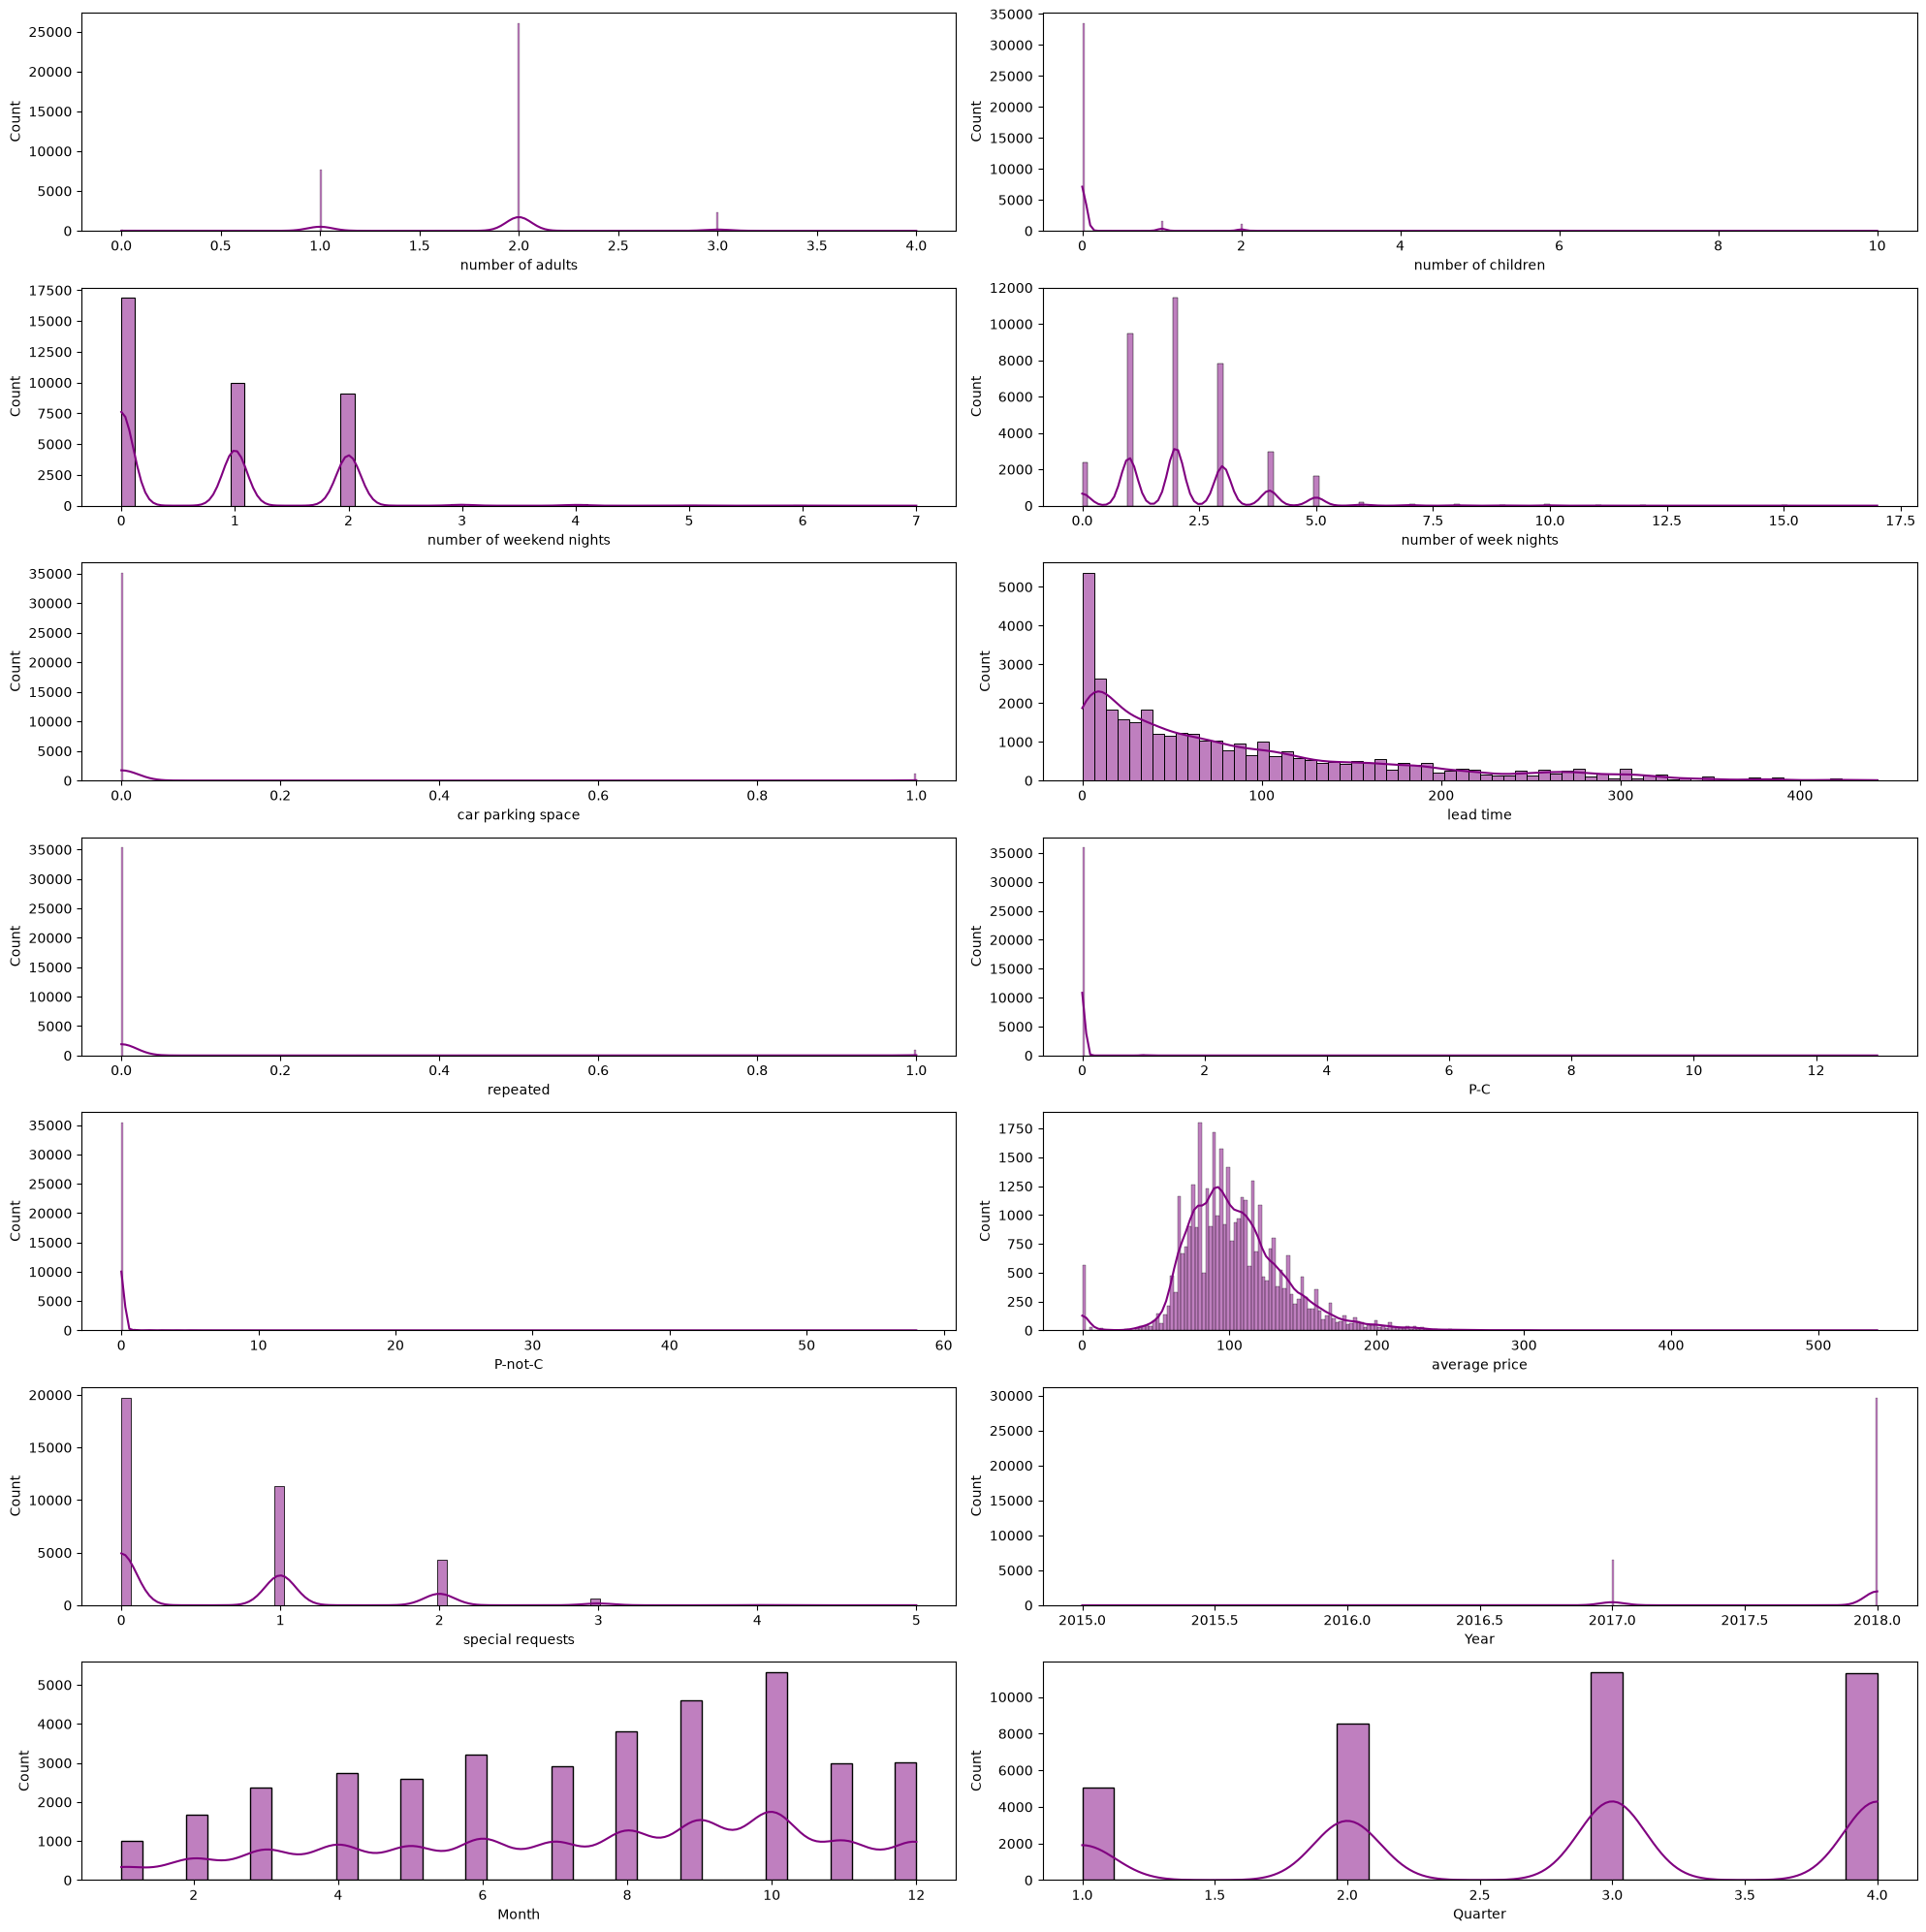

In [23]:
fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(20, 20))
ax = ax.flatten()

for index, column_name in enumerate(numerical_columns):
    sns.histplot(data[column_name], kde= True, color= 'purple', ax=ax[index])

plt.tight_layout()
plt.show()

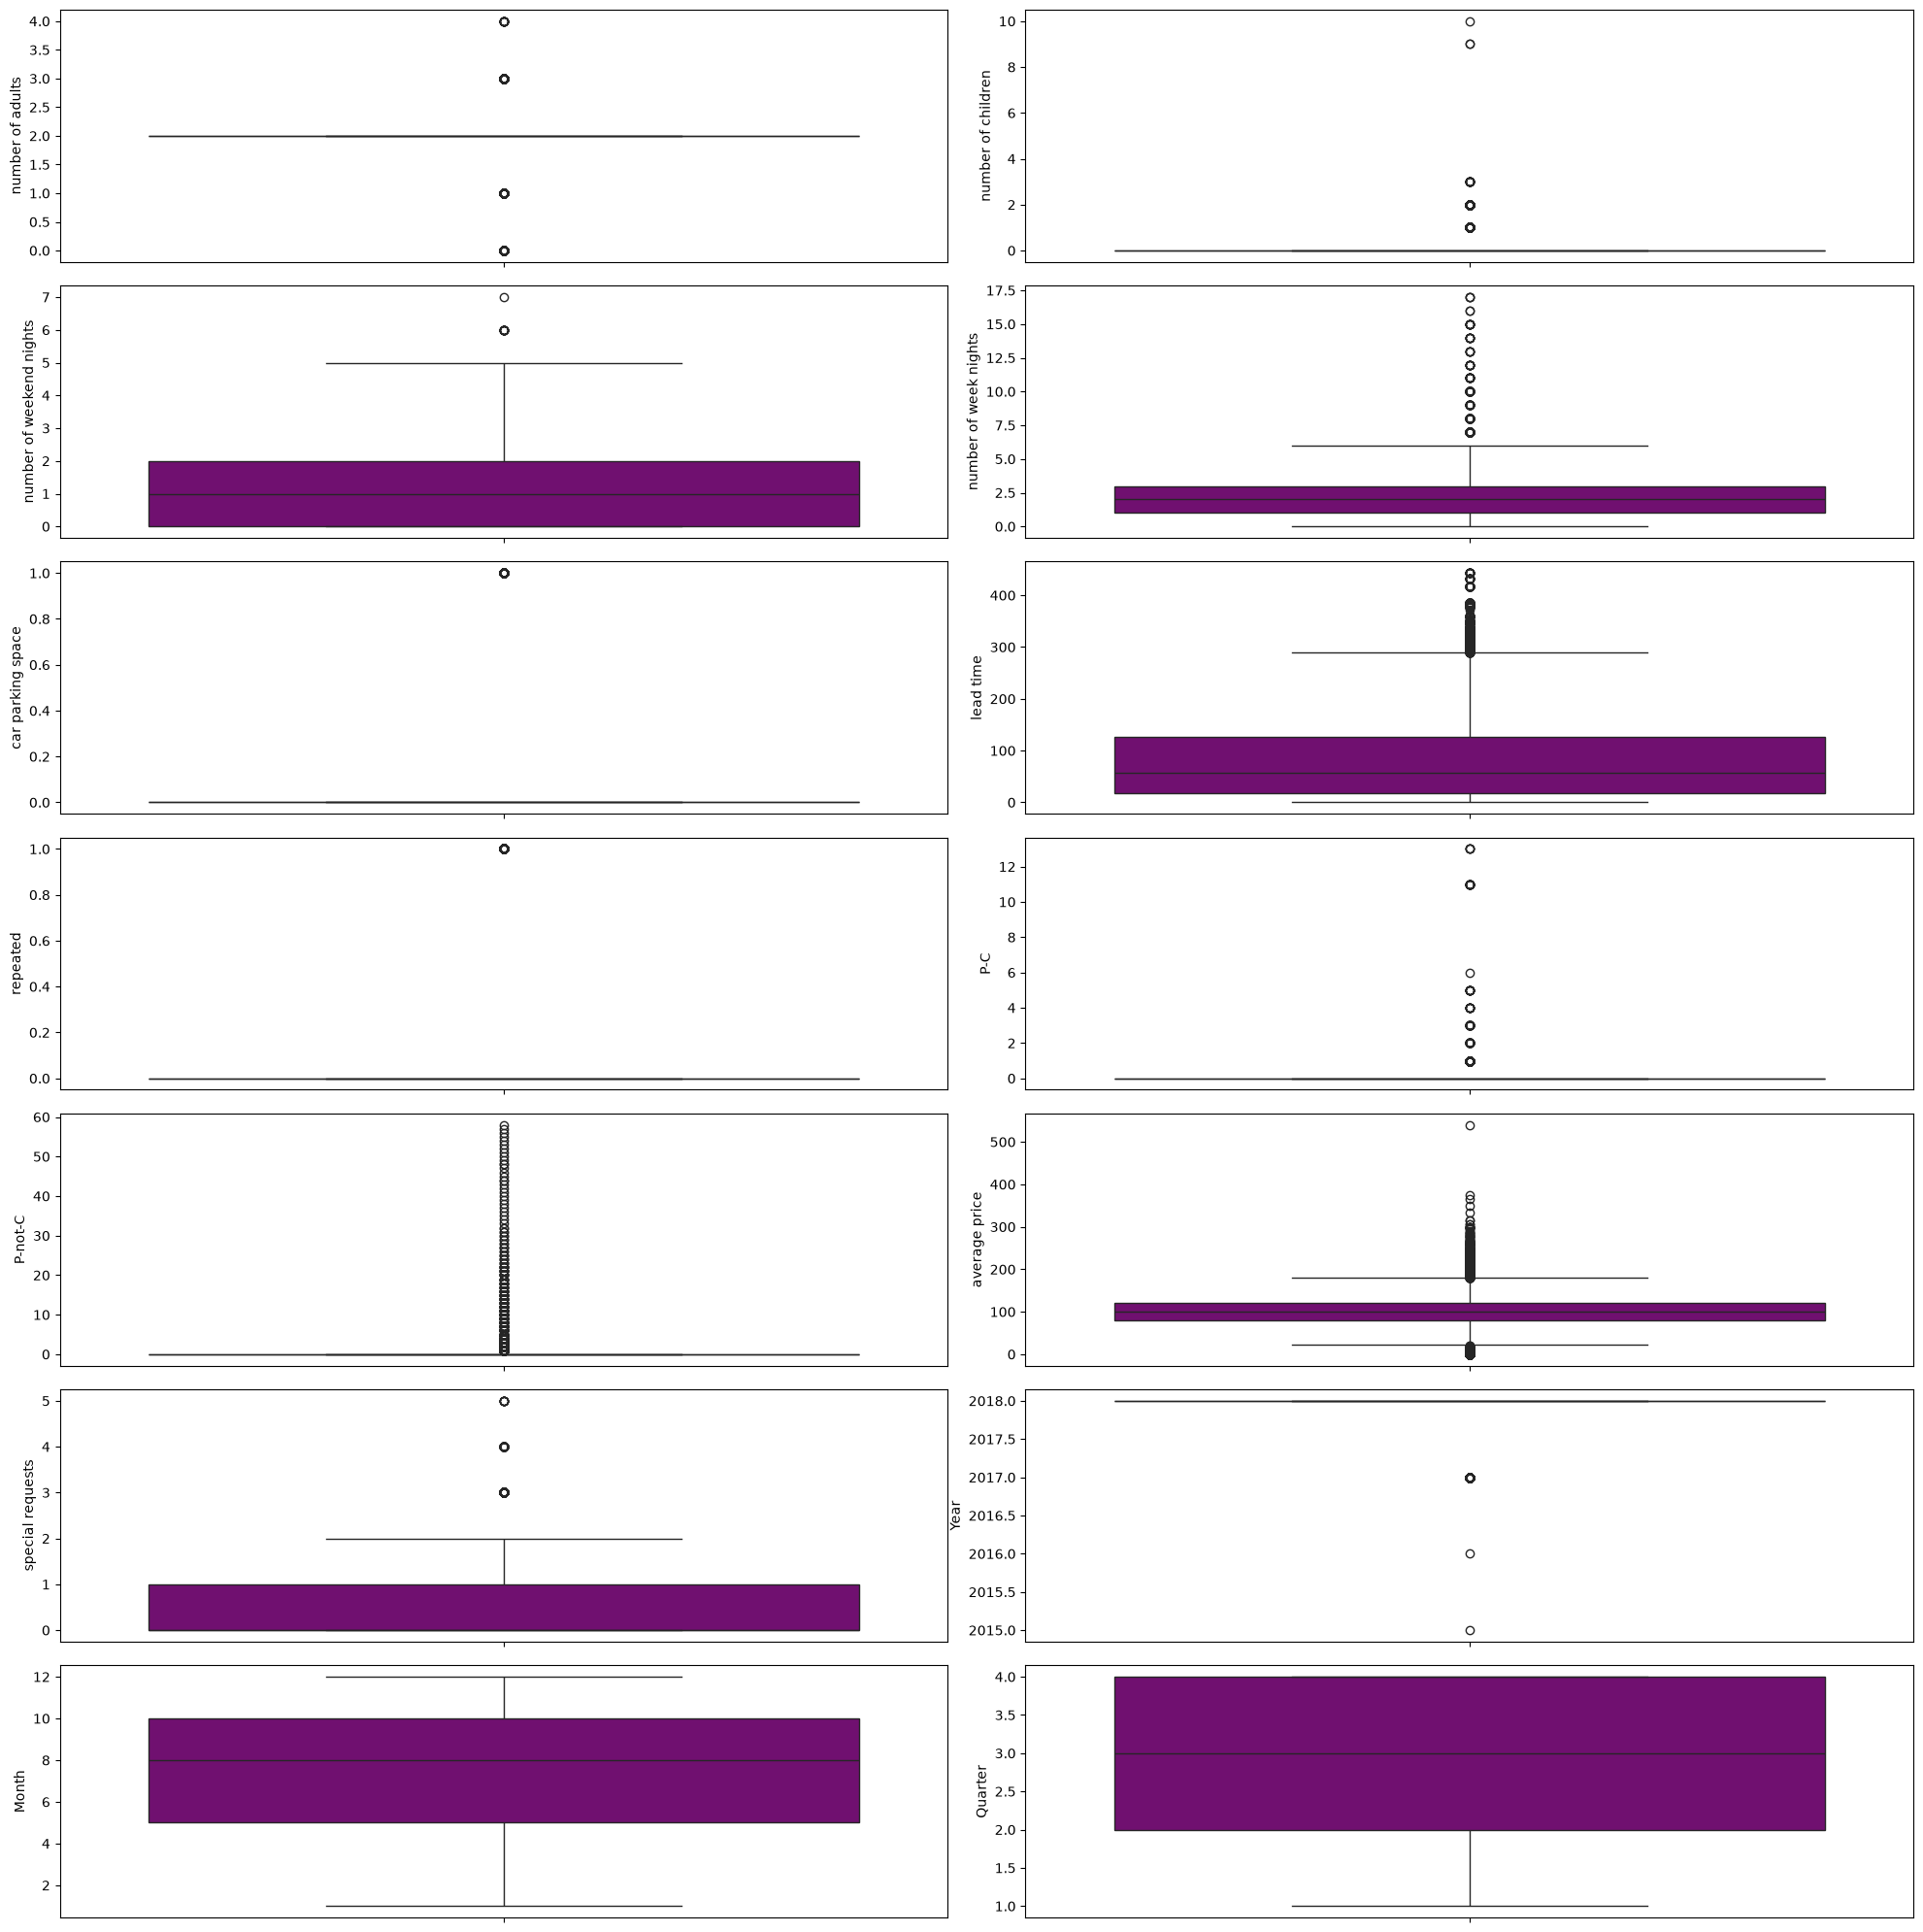

In [24]:
fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(20, 20))
ax = ax.flatten()

for index, column_name in enumerate(numerical_columns):
    sns.boxplot(data[column_name], color= 'purple', ax=ax[index])

plt.tight_layout()
plt.show()

#### The boxplots and histplot showed possible outliers in some numerical columns, especially lead time and average price. These values were retained because they may represent real booking behavior rather than data errors. For example, some customers may book far in advance or pay higher prices depending on room type, season, or booking conditions. Since these values can help explain cancellation patterns, they were kept for the analysis and model building.

In [25]:
# Target Column

In [26]:
data['booking status'].value_counts()

booking status
Not_Canceled    24366
Canceled        11882
Name: count, dtype: int64

In [27]:
data['booking status'].value_counts(normalize=True)*100

booking status
Not_Canceled    67.22026
Canceled        32.77974
Name: proportion, dtype: float64

In [28]:
from collections import Counter

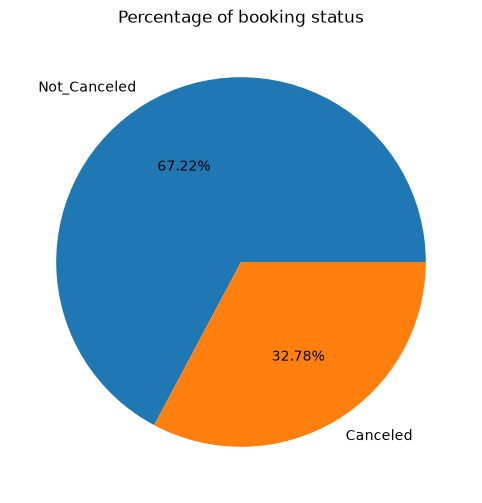

In [29]:
# Percentage of booking status

fig,ax=plt.subplots(figsize=(6,6))
count= Counter(data['booking status'])
ax.pie(count.values(), labels=count.keys(),autopct=lambda p:f'{p:.2f}%')
ax.set_title('Percentage of booking status')
plt.show()

#### The target variable is booking status, which shows whether each booking was canceled or not canceled. The final dataset contained 36,246 bookings, with 24,365 not canceled bookings and 11,881 canceled bookings. This means 67.22% of bookings were not canceled, while 32.78% were canceled.This shows that almost one in every three bookings was canceled, making cancellation prediction important for business planning.

In [30]:
data.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'market segment type', 'repeated', 'P-C',
       'P-not-C', 'average price', 'special requests', 'booking status',
       'Year', 'Month', 'Month_name', 'Quarter', 'Day_of_week'],
      dtype='str')

In [31]:
data.Year

0        2015
1        2018
2        2018
3        2017
4        2018
         ... 
36280    2018
36281    2017
36282    2018
36283    2018
36284    2018
Name: Year, Length: 36248, dtype: int32

In [32]:
data['Year'].value_counts().sort_index()

Year
2015        1
2016        1
2017     6516
2018    29730
Name: count, dtype: int64

In [33]:
data[data['Year'].isin([2015, 2016])]

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status,Year,Month,Month_name,Quarter,Day_of_week
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.0,0,Not_Canceled,2015,10,October,4,Friday
5,1,0,0,2,Meal Plan 2,0,Room_Type 1,346,Offline,0,0,0,100.0,1,Canceled,2016,9,September,3,Tuesday


In [34]:
data= data[~data['Year'].isin([2015, 2016])]

In [35]:
data.reset_index(drop=True, inplace=True)

In [36]:
data['Year'].value_counts().sort_index()

Year
2017     6516
2018    29730
Name: count, dtype: int64

#### The Year column was reviewed to check the distribution of bookings across years. Records from 2015 and 2016 were removed because they had very few observations compared to the main years in the dataset.

### Exploratory Data Analysis

In [37]:
# Categorical Columns

In [38]:
data.columns

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'type of meal', 'car parking space',
       'room type', 'lead time', 'market segment type', 'repeated', 'P-C',
       'P-not-C', 'average price', 'special requests', 'booking status',
       'Year', 'Month', 'Month_name', 'Quarter', 'Day_of_week'],
      dtype='str')

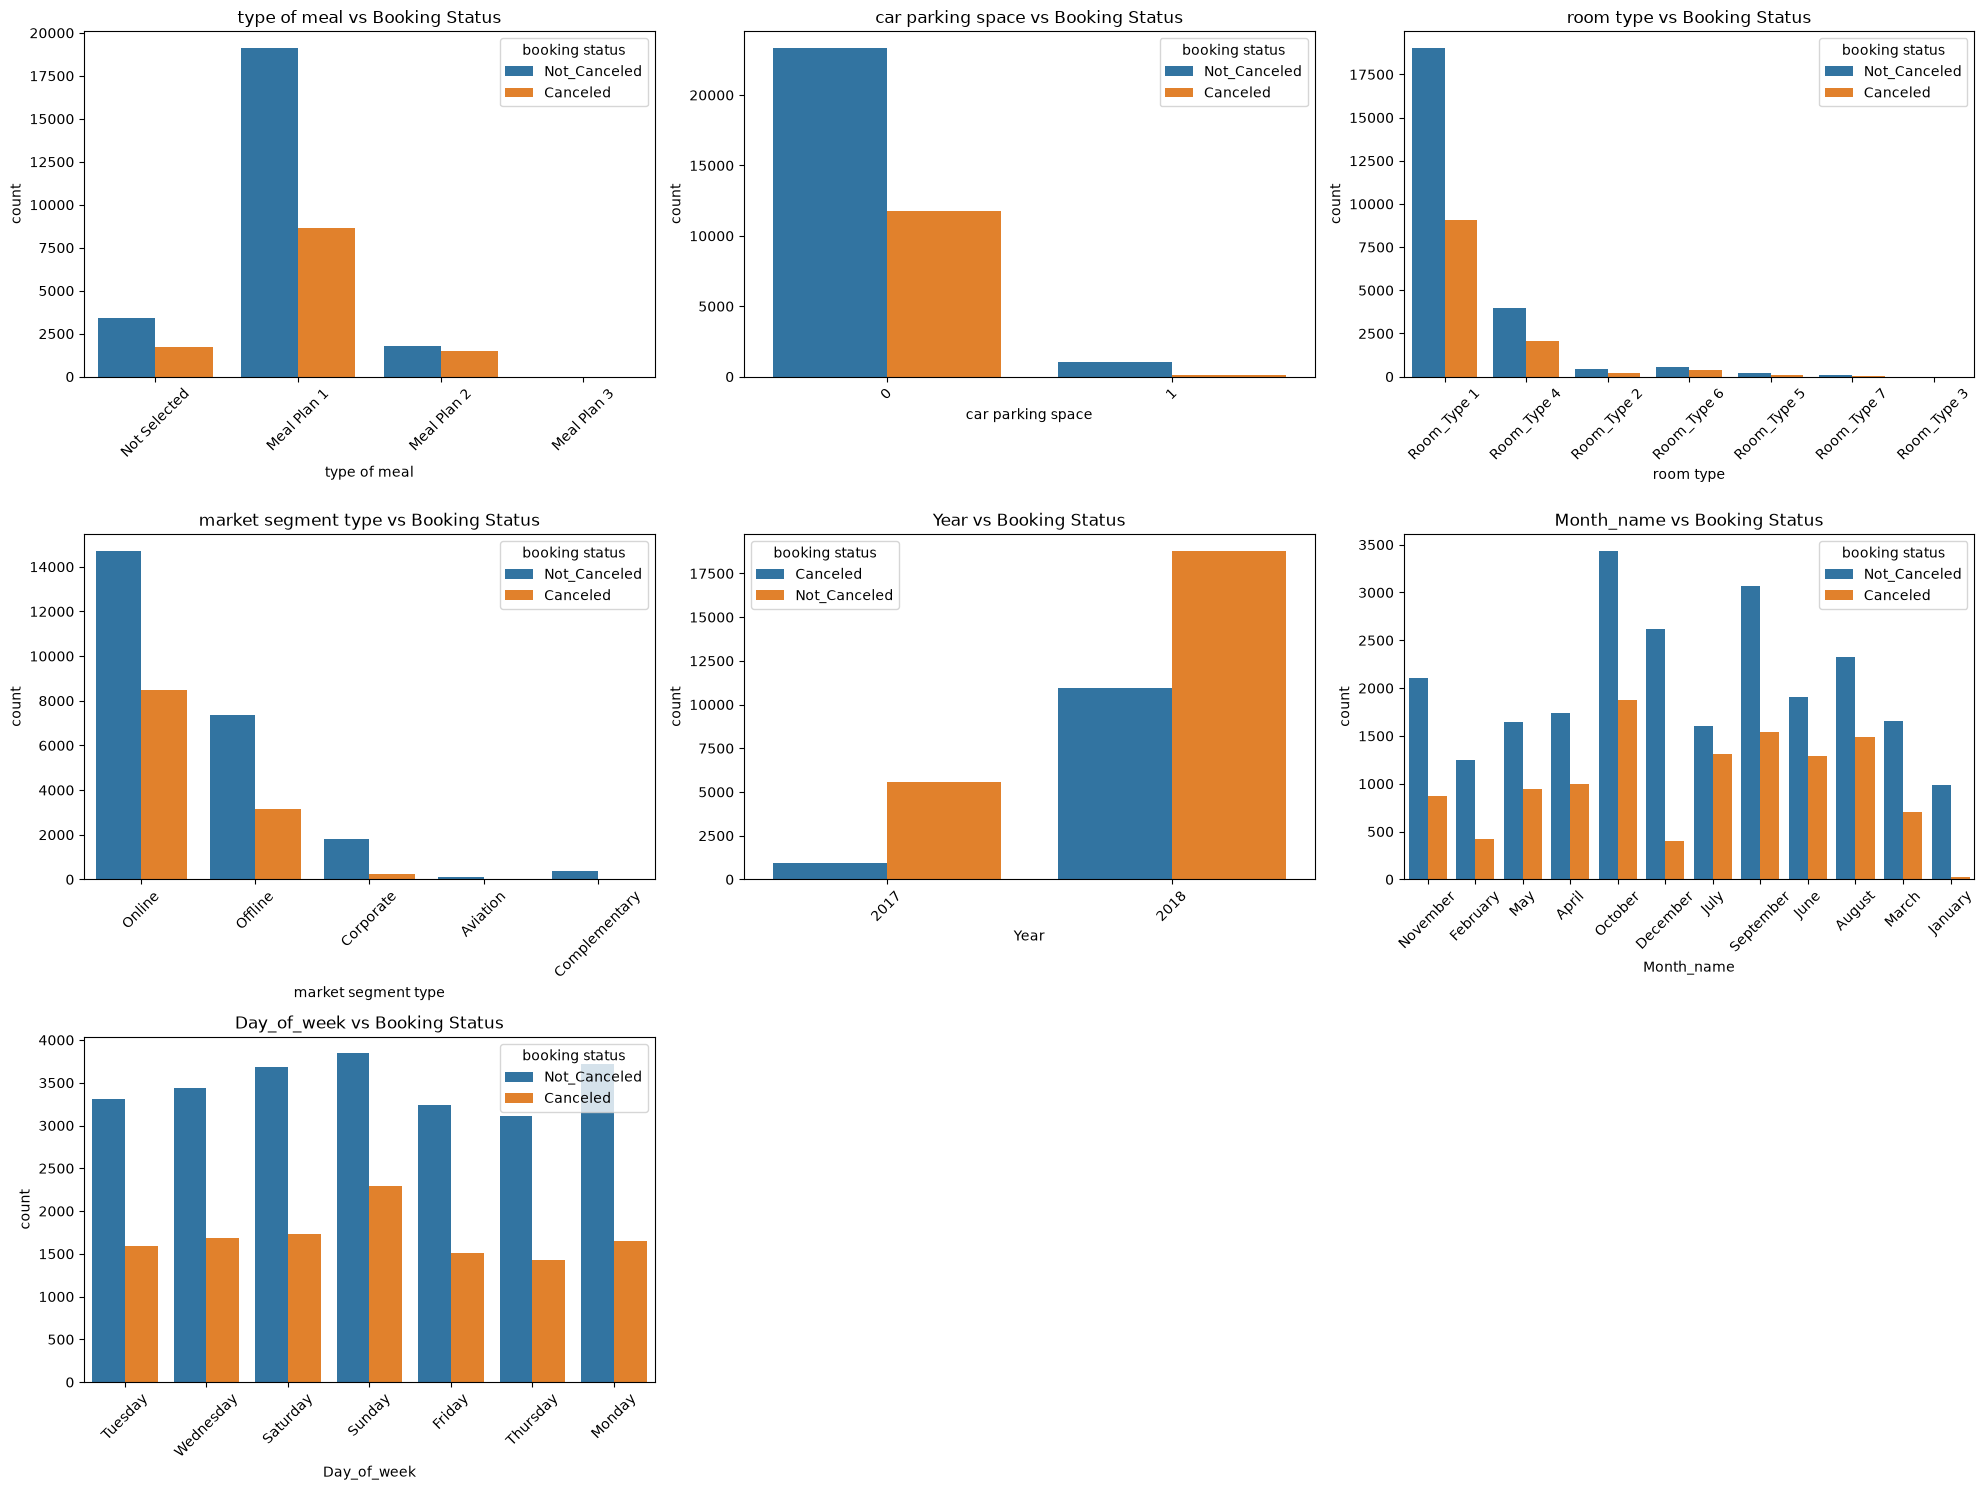

In [39]:
categorical_cols =[
    'type of meal',
    'car parking space',
    'room type', 
    'market segment type',
    'Year', 
    'Month_name', 
    'Day_of_week'
]
    
plt.figure(figsize=(20,15))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=data, x=col, hue='booking status')
    plt.title(f'{col} vs Booking Status')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Categorical features such as meal type, car parking space, room type, market segment type, month, year, and day of week were compared with booking status. This helped identify how cancellation behavior varied across customer segments, booking periods, and reservation characteristics.

In [40]:
# Numerical columns

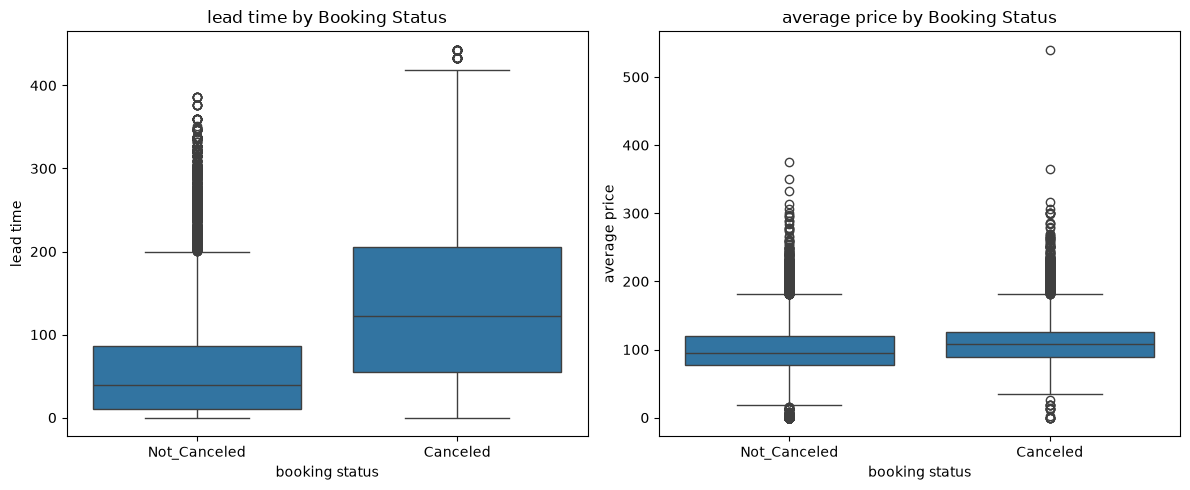

In [41]:
numerical_cols = ['lead time', 'average price']

plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=data, x='booking status', y=col)
    plt.title(f'{col} by Booking Status')

plt.tight_layout()
plt.show()

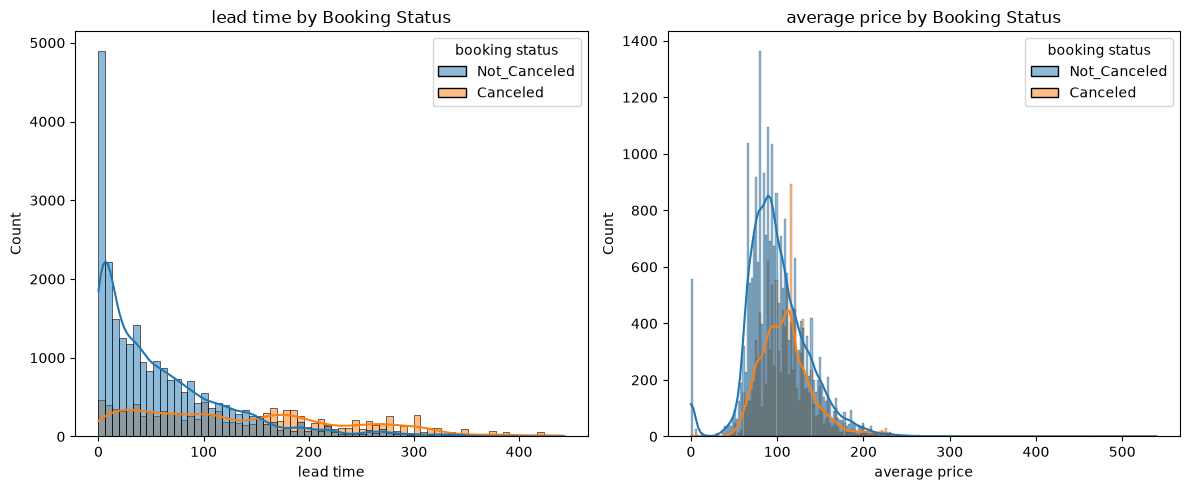

In [42]:
numerical_cols = ['lead time', 'average price']

plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(data=data, x=col, hue='booking status', kde=True)
    plt.title(f'{col} by Booking Status')

plt.tight_layout()
plt.show()

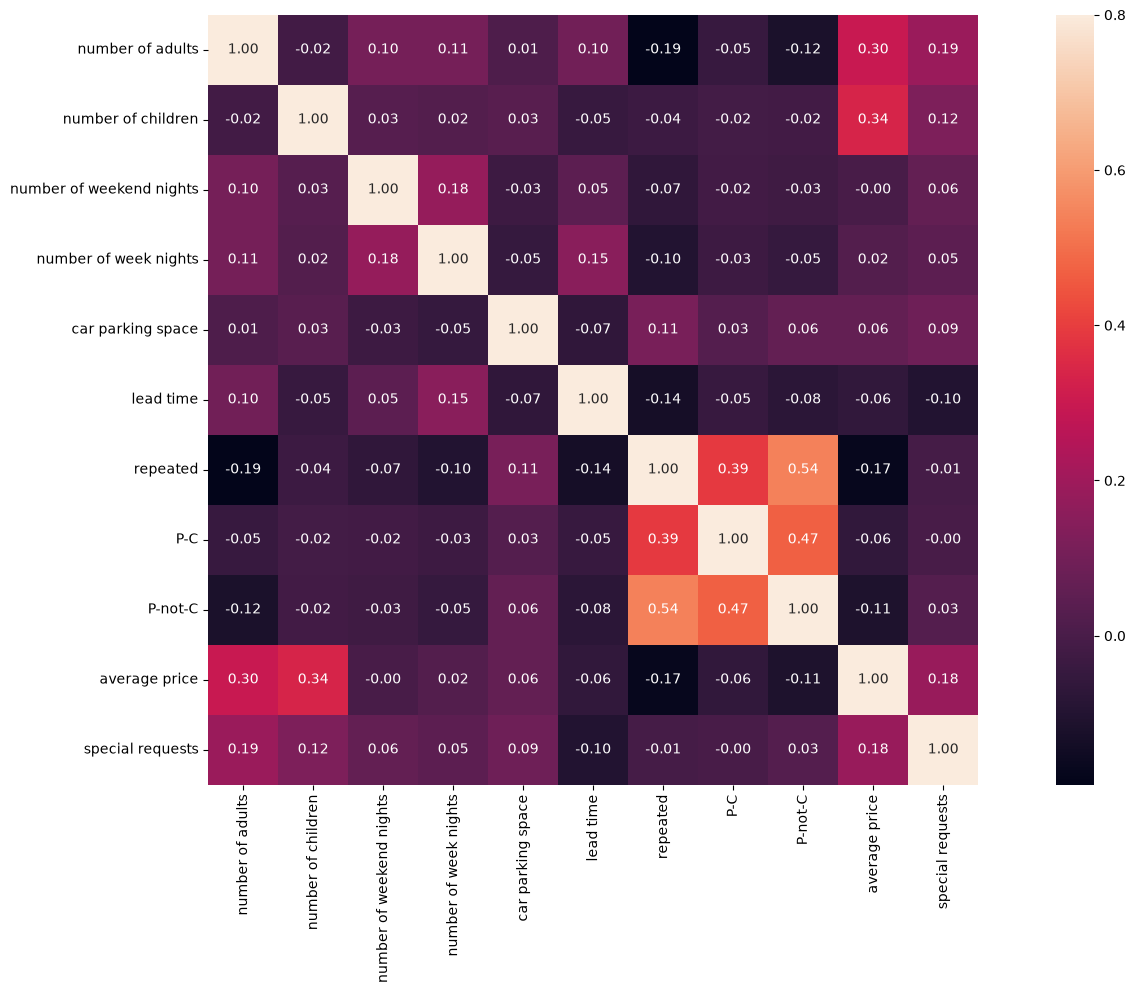

In [43]:
a= data.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(20, 10))
sns.heatmap(a, vmax= .8,square= True, annot= True, fmt='.2f');

#### Lead time and average price were compared against booking status. The analysis showed that canceled bookings generally had higher lead times, suggesting that customers who book far in advance may be more likely to cancel. Average price also showed some relationship with cancellation, although the pattern was not as strong as lead time.

In [44]:
data['booking_status_encoded'] = data['booking status'].map({
    'Not_Canceled': 0,
    'Canceled': 1
})

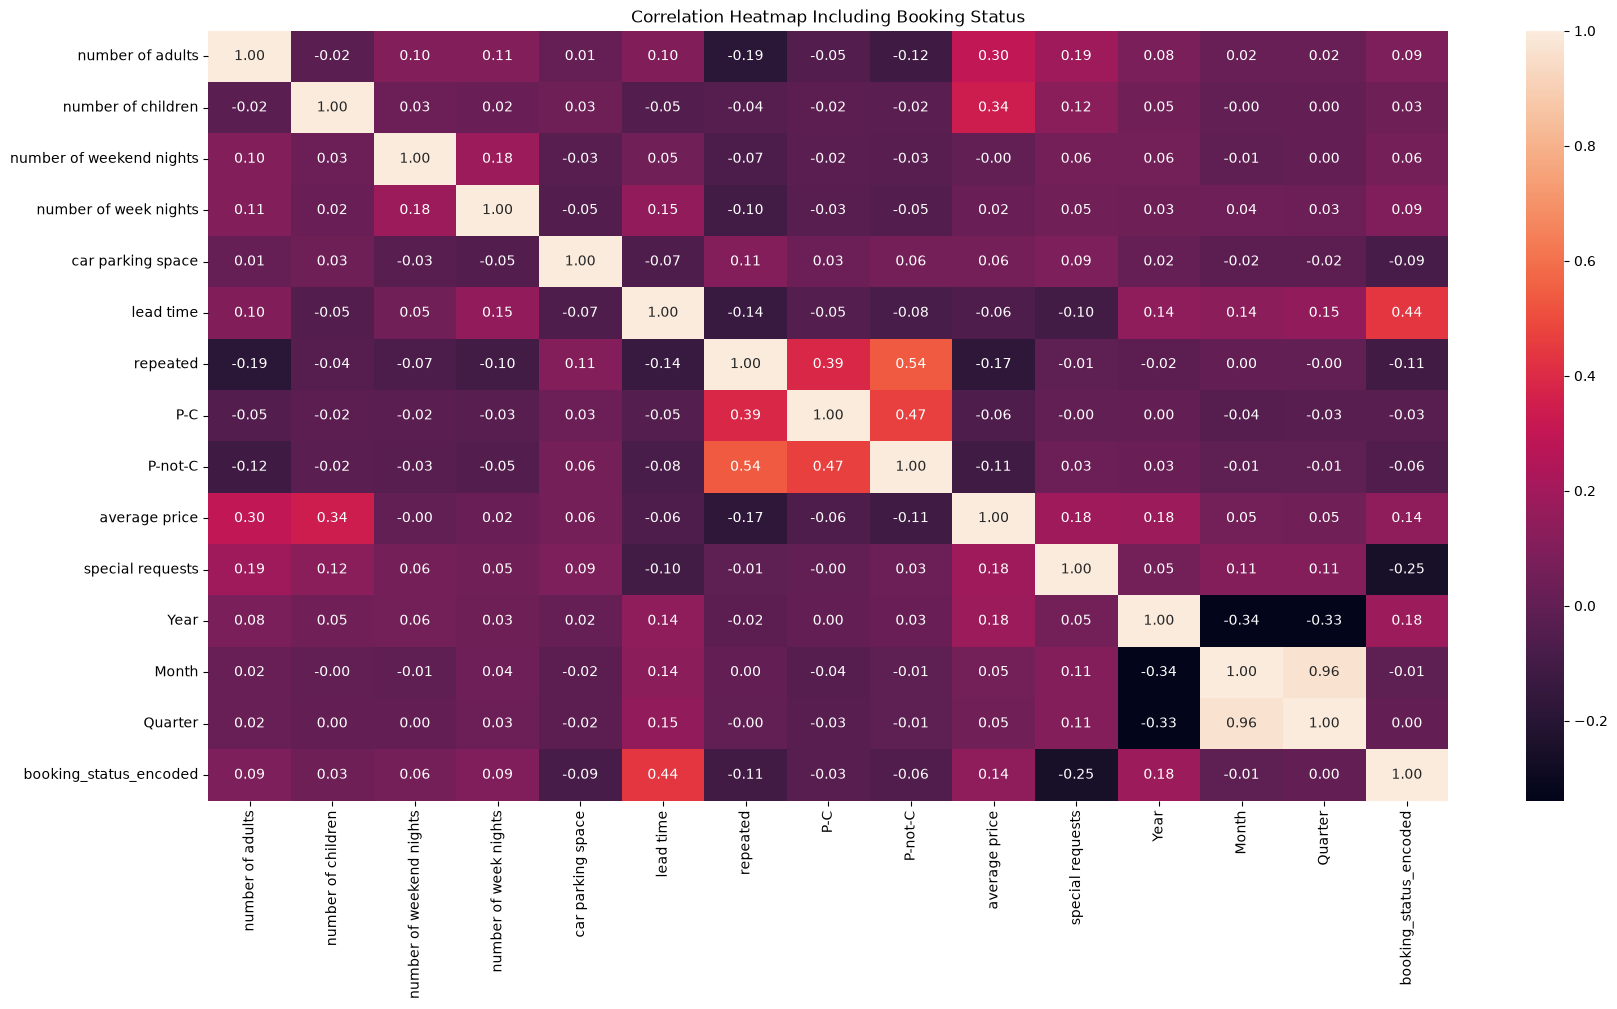

In [45]:
numeric_data = data.select_dtypes(include=['int64', 'float64', 'int32'])

plt.figure(figsize=(20, 10))
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap Including Booking Status')
plt.show()

#### A correlation heatmap was used to examine the relationships among numerical variables, including the encoded booking status. Most variables had weak linear relationships with booking status, which suggests that cancellation behavior may depend on a combination of several features rather than one feature alone.

### Pre-processing

In [46]:
data.isnull().sum()

number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
booking status              0
Year                        0
Month                       0
Month_name                  0
Quarter                     0
Day_of_week                 0
booking_status_encoded      0
dtype: int64

In [47]:
data.duplicated().sum()

np.int64(10336)

#### Duplicate rows appeared after removing unique columns like Booking_ID and date of reservation. These rows are retained because they may represent different bookings with similar details.

In [48]:
data.drop('Month_name', axis=1, inplace=True)

In [49]:
data.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status,Year,Month,Quarter,Day_of_week,booking_status_encoded
0,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018,11,4,Tuesday,0
1,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,Canceled,2018,2,1,Wednesday,1


In [50]:
x = data.drop(['booking status', 'booking_status_encoded'], axis=1)
y = data['booking_status_encoded']

In [51]:
x.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,Year,Month,Quarter,Day_of_week
0,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018,11,4,Tuesday
1,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018,2,1,Wednesday
2,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017,5,2,Saturday
3,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018,4,2,Wednesday
4,1,1,1,4,Meal Plan 1,0,Room_Type 1,34,Online,0,0,0,107.55,1,2017,10,4,Sunday


In [52]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: booking_status_encoded, dtype: int64

In [53]:
x.shape, y.shape

((36246, 18), (36246,))

#### The booking status column was encoded into numerical form so it could be used for machine learning. The feature variables were separated from the target variable. Booking status and the encoded target column were removed from the feature set to avoid data leakage.

### Data Splitting

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
# features = x variables
# target = y variables

In [57]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((28996, 18), (7250, 18), (28996,), (7250,))

#### The data was split into training and testing sets. Stratified splitting was used so that the proportion of canceled and not-canceled bookings remained similar in both the training and testing data.

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [59]:
categorical_cols = x.select_dtypes(include='object').columns
numerical_cols = x.select_dtypes(include=['int64', 'int32', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

C:\Users\olade\AppData\Local\Temp\ipykernel_36524\3701449326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include='object').columns


In [60]:
categorical_cols

Index(['type of meal', 'room type', 'market segment type', 'Day_of_week'], dtype='str')

In [61]:
numerical_cols

Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price', 'special requests', 'Year', 'Month',
       'Quarter'],
      dtype='str')

In [62]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

#### A preprocessing pipeline was created to prepare the data for machine learning. Numerical features were scaled using StandardScaler, while categorical features were converted into numerical form using OneHotEncoder.

### Logistic regression model

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [64]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])


In [65]:
log_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['number of adults','number of children','number of weekend nights',..., 'Month','Quarter','Day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [66]:
# Predict on the test set

In [67]:
y_pred = log_model.predict(x_test)

In [68]:
# Evaluate performance

In [69]:
from sklearn.metrics import accuracy_score

Accuracy: 0.7806896551724138
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4874
           1       0.64      0.77      0.70      2376

    accuracy                           0.78      7250
   macro avg       0.76      0.78      0.76      7250
weighted avg       0.80      0.78      0.79      7250

[[3823 1051]
 [ 539 1837]]


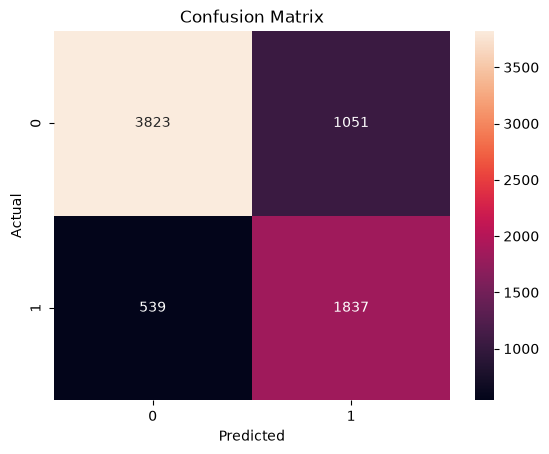

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

matrix = confusion_matrix(y_test, y_pred)

print(matrix)

sns.heatmap(matrix, annot=True, fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [71]:
y.value_counts(normalize=True) * 100

booking_status_encoded
0    67.221211
1    32.778789
Name: proportion, dtype: float64

#### Logistic Regression was trained as a baseline model. The model achieved 78.07% accuracy. Although it performed reasonably well, it was weaker than Random Forest and other advanced models in overall performance.

### Random Forest Model

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
# Train random forest model

In [74]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

In [75]:
rf_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['number of adults','number of children','number of weekend nights',..., 'Month','Quarter','Day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [76]:
# Predict on the test set

In [77]:
y_pred_rf = rf_model.predict(x_test)

In [78]:
# Evaluate performance

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Random Forest Accuracy: 0.900551724137931
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4874
           1       0.85      0.85      0.85      2376

    accuracy                           0.90      7250
   macro avg       0.89      0.89      0.89      7250
weighted avg       0.90      0.90      0.90      7250

[[4512  362]
 [ 359 2017]]


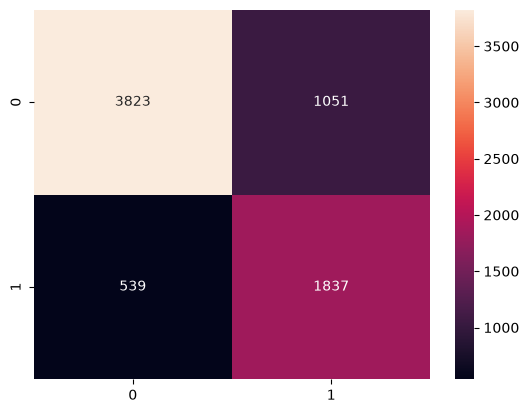

In [80]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
sns.heatmap(matrix, annot=True, fmt="g")
plt.show()

#### Random Forest was trained as an advanced classification model. It performed better than Logistic Regression, achieving 90.34% accuracy. The model was better at identifying both canceled and not-canceled bookings.

### Model Comparison

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [82]:
# Define the models
# class_weights={0:1, 1:3}
class_weights='balanced'
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Support Vector Machine': SVC(random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier( random_state=42,eval_metric='logloss')
}

In [83]:
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix
    }

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(report)
    print(matrix)
    print("-" * 50)

Training Logistic Regression...
Logistic Regression Accuracy: 0.7807
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4874
           1       0.64      0.77      0.70      2376

    accuracy                           0.78      7250
   macro avg       0.76      0.78      0.76      7250
weighted avg       0.80      0.78      0.79      7250

[[3823 1051]
 [ 539 1837]]
--------------------------------------------------
Training Random Forest...
Random Forest Accuracy: 0.9006
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4874
           1       0.85      0.85      0.85      2376

    accuracy                           0.90      7250
   macro avg       0.89      0.89      0.89      7250
weighted avg       0.90      0.90      0.90      7250

[[4512  362]
 [ 359 2017]]
--------------------------------------------------
Training Support Vector Machine...
Support Vector Machine Accura

### Compare all model results

In [84]:
summary = []

for model_name, result in results.items():
    summary.append({
        'Model': model_name,
        'Accuracy': result['accuracy']
    })

summary_data = pd.DataFrame(summary).sort_values(by='Accuracy', ascending=False)
summary_data

,Model,Accuracy
1,Random Forest,0.900552
7,XGBoost,0.887172
4,Decision Tree,0.867724
5,Gradient Boosting,0.855724
3,K-Nearest Neighbors,0.843172
2,Support Vector Machine,0.829793
6,AdaBoost,0.810069
0,Logistic Regression,0.780690


In [85]:
results.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'Support Vector Machine', 'K-Nearest Neighbors', 'Decision Tree', 'Gradient Boosting', 'AdaBoost', 'XGBoost'])

#### Several classification models were tested and compared, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, K-Nearest Neighbors, Support Vector Machine, and XGBoost. Random Forest achieved the highest accuracy at 90.34%, followed by XGBoost at 88.73%. Based on the comparison, Random Forest was the strongest model.

### Model Selection and Hyperparameter Tuning Using GridSearchCV

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [87]:
# Full param_grid with all models

In [88]:
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)],
        'classifier__C': [0.1, 1, 10]
    },
    {
        'classifier': [DecisionTreeClassifier(class_weight='balanced', random_state=42)],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5]
    },
    {
        'classifier': [RandomForestClassifier(class_weight='balanced', random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    },
    {
        'classifier': [GradientBoostingClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    },
    {
        'classifier': [AdaBoostClassifier(random_state=42)],
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.5, 1.0]
    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7],
        'classifier__weights': ['uniform', 'distance']
    },
    {'classifier': [XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )],
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
    }
]

In [89]:
# Run GridSearchCV

In [90]:
grid_search_all = GridSearchCV(
    estimator=model_pipe,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search_all.fit(x_train, y_train)

Fitting 3 folds for each of 59 candidates, totalling 177 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [LogisticRegre...ndom_state=42)], 'classifier__C': [0.1, 1, ...]}, {'classifier': [DecisionTreeC...ndom_state=42)], 'classifier__max_depth': [10, 20, ...], 'classifier__min_samples_split': [2, 5]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``

In [91]:
# Print best model and best parameters

In [92]:
print("Best Model:", grid_search_all.best_estimator_.named_steps['classifier'])
print("Best Parameters:", grid_search_all.best_params_)
print("Best F1 Score:", grid_search_all.best_score_)

Best Model: RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=200, random_state=42)
Best Parameters: {'classifier': RandomForestClassifier(class_weight='balanced', random_state=42), 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best F1 Score: 0.8366461247390417


In [93]:
best_rf_model = grid_search_all.best_estimator_

#### GridSearchCV was used to compare selected classification models and test different hyperparameter combinations. The goal was to identify the best-performing model based on F1-score. GridSearchCV returned Random Forest as the best model, this confirmed that Random Forest remained the best-performing model in the model selection process.

### Tuned Random Forest Model Evaluation

In [94]:
# Predict using best_rf_model
y_pred_best_rf = best_rf_model.predict(x_test)

In [95]:
# Evaluate best_rf_model
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.9019310344827586
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      4874
           1       0.84      0.86      0.85      2376

    accuracy                           0.90      7250
   macro avg       0.89      0.89      0.89      7250
weighted avg       0.90      0.90      0.90      7250



[[4489  385]
 [ 326 2050]]

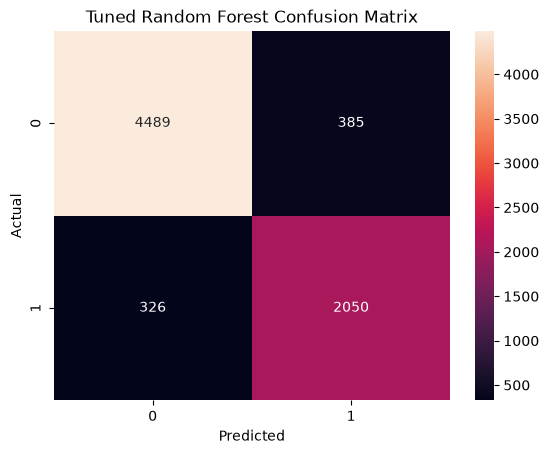

In [96]:
# Confusion matrix
matrix = confusion_matrix(y_test, y_pred_best_rf)
print(matrix)

sns.heatmap(matrix, annot=True, fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

#### The tuned Random Forest model achieved 90.36% accuracy. It correctly identified 2,007 canceled bookings and missed 369 canceled bookings in the test data. This shows that the tuned model performed strongly in identifying cancellation patterns and separating canceled bookings from not-canceled bookings.

### ROC Curve and AUC Score for Tuned Random Forest

In [97]:
from sklearn.metrics import roc_curve, roc_auc_score

In [98]:
# Get predicted probabilities for class 1 = Canceled
y_pred_probs_rf =best_rf_model.predict_proba(x_test)[:, 1]

In [99]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs_rf)

In [100]:
# Calculate AUC score
auc_score_rf = roc_auc_score(y_test, y_pred_probs_rf)

In [101]:
print("Tuned Random Forest AUC Score:", auc_score_rf)

Tuned Random Forest AUC Score: 0.9577529241947583


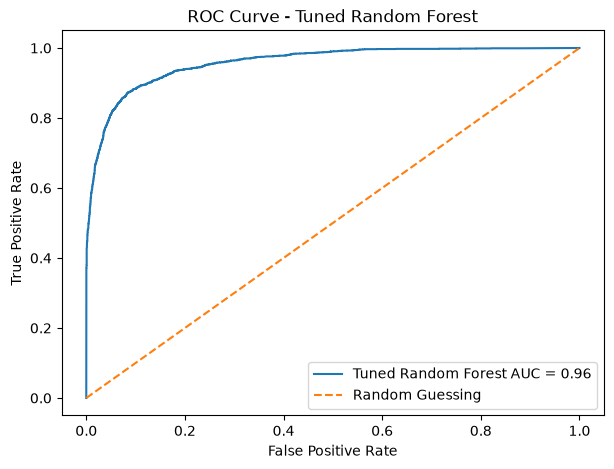

In [102]:
# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Tuned Random Forest AUC = {auc_score_rf:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.show()

#### The ROC curve and AUC score were used to evaluate how well the Tuned Random Forest model distinguishes between canceled and not-canceled bookings. The model achieved an AUC score of 95.78%, which indicates strong classification performance.

### Feature Importance for Tuned Random Forest

In [103]:
best_model = best_rf_model

feature_names = best_rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf_model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
5,num__lead time,0.309082
9,num__average price,0.142307
10,num__special requests,0.128906
12,num__Month,0.075871
3,num__number of week nights,0.046096
29,cat__market segment type_Online,0.031858
2,num__number of weekend nights,0.031508
11,num__Year,0.030554
13,num__Quarter,0.025182
0,num__number of adults,0.023523


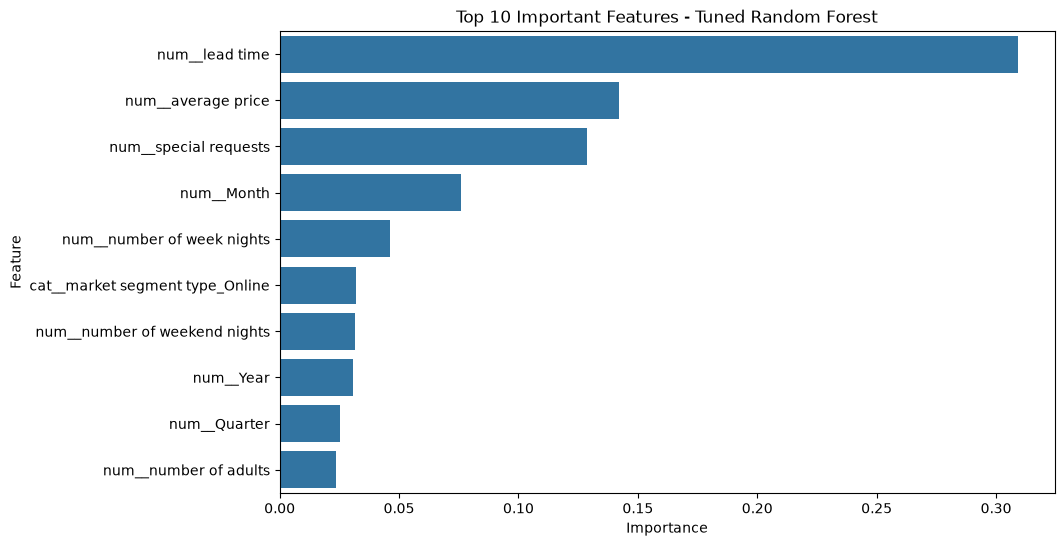

In [104]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Important Features - Tuned Random Forest')
plt.show()

#### The feature importance analysis from the Tuned Random Forest model showed that lead time was the most influential predictor of booking cancellation. This suggests that the number of days between booking and arrival plays a major role in whether a customer cancels. Average price and special requests were also important, indicating that booking cost and customer preferences may influence cancellation behavior. Month and length-of-stay features also contributed to the model, showing that seasonal and stay-duration patterns may affect cancellations.

### Conclusion

#### The analysis showed that booking cancellations are a significant issue for Hotel Haven, with 32.78% of bookings canceled. 
#### Several classification models were tested, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, K-Nearest Neighbors, Support Vector Machine, and XGBoost. Random Forest performed best during model comparison, and GridSearchCV also returned Random Forest as the best-performing model after comparing selected models and hyperparameter combinations. 
#### The tuned Random Forest model achieved 90.36% accuracy and a 95.78% AUC score.
#### The most important predictors of cancellation were lead time, average price, special requests, booking month, length of stay, and market segment. 
#### Based on these findings, Hotel Haven can flag high-risk bookings earlier, monitor long lead-time bookings, and use cancellation risk insights to support room planning, staffing, revenue forecasting, and customer retention.